# Лабораторная работа №3

### Введение

Для выбранного датасета (датасетов) на основе материалов лекции решить следующие задачи:

1. Выберите набор данных (датасет) для решения задачи классификации или регрессии.
2. В случае необходимости проведите удаление или заполнение пропусков и кодирование категориальных признаков.
3. С использованием метода train_test_split разделите выборку на обучающую и тестовую.
4. Обучите модель ближайших соседей для произвольно заданного гиперпараметра K. Оцените качество модели с помощью подходящих для задачи метрик.
5. Произведите подбор гиперпараметра K с использованием GridSearchCV и RandomizedSearchCV и кросс-валидации, оцените качество оптимальной модели. Используйте не менее двух стратегий кросс-валидации.
6. Сравните метрики качества исходной и оптимальной моделей.

### 1) Выбор датасета
В качестве набора данных будем использовать датасет "Wine reviews". В датасете содержится информация о сортах вин. 

**Ссылка на датасет**: https://www.kaggle.com/datasets/yasserh/wine-quality-dataset/data

Датасет содержит следующие поля.
1. **fixed acidity**         - Фиксированное значение кислотности
2. **volatile acidity**      - Значение летучей кислотности
3. **citric acid**           - Значение лимонной кислоты
4. **residual sugar**        - Значение остаточного сахара
5. **chlorides**             - Количество хлоридов
6. **free sulfur dioxide**   - Количество свободного диоксида серы
7. **total sulfur dioxide**  - Общее количество диоксида серы
8. **density**               - Значение плотности
9. **pH**                    - Значение рН
10. **sulphates**            - Содержание сульфатов
11. **alcohol**              - Содержание алкоголя
12. **quality**              - Целевое качество (оценка от 0 до 10)
13. **id**                   - Номер по списку

### 2) Очистка датасета

Импортируем библиотеки с помощью команды import.

In [37]:
%matplotlib notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from scipy.stats import randint

Загрузим файлы датасета в помощью библиотеки Pandas. Проверим данные на предмет присутствия пропусков, выбросов и пр. Также немного преобразуем данные для более эффективного хранения памяти и удобного использования в будущем.

In [38]:
data = pd.read_csv('WineQT.csv')
data.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5,6
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7,8
9,6.7,0.58,0.08,1.8,0.097,15.0,65.0,0.9959,3.28,0.54,9.2,5,10


In [39]:
# Проверка на пропуски
print("Пропуски до обработки:")
print(data.isna().sum())

Пропуски до обработки:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


In [40]:
# Размер датасета - 1143 строки, 13 колонок
data.shape

(1143, 13)

In [41]:
total_count = data.shape[0]
print('Всего строк: {}'.format(total_count))
# Список колонок
# df.columns
# Список колонок с типами данных
data.dtypes

Всего строк: 1143


fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
Id                        int64
dtype: object

In [42]:
# Основные статистики для числовых полей
print(data.describe())

       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1143.000000       1143.000000  1143.000000     1143.000000   
mean        8.311111          0.531339     0.268364        2.532152   
std         1.747595          0.179633     0.196686        1.355917   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.392500     0.090000        1.900000   
50%         7.900000          0.520000     0.250000        2.200000   
75%         9.100000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1143.000000          1143.000000           1143.000000  1143.000000   
mean      0.086933            15.615486             45.914698     0.996730   
std       0.047267            10.250486             32.782130     0.001925   
min       0.012000             1.000000         

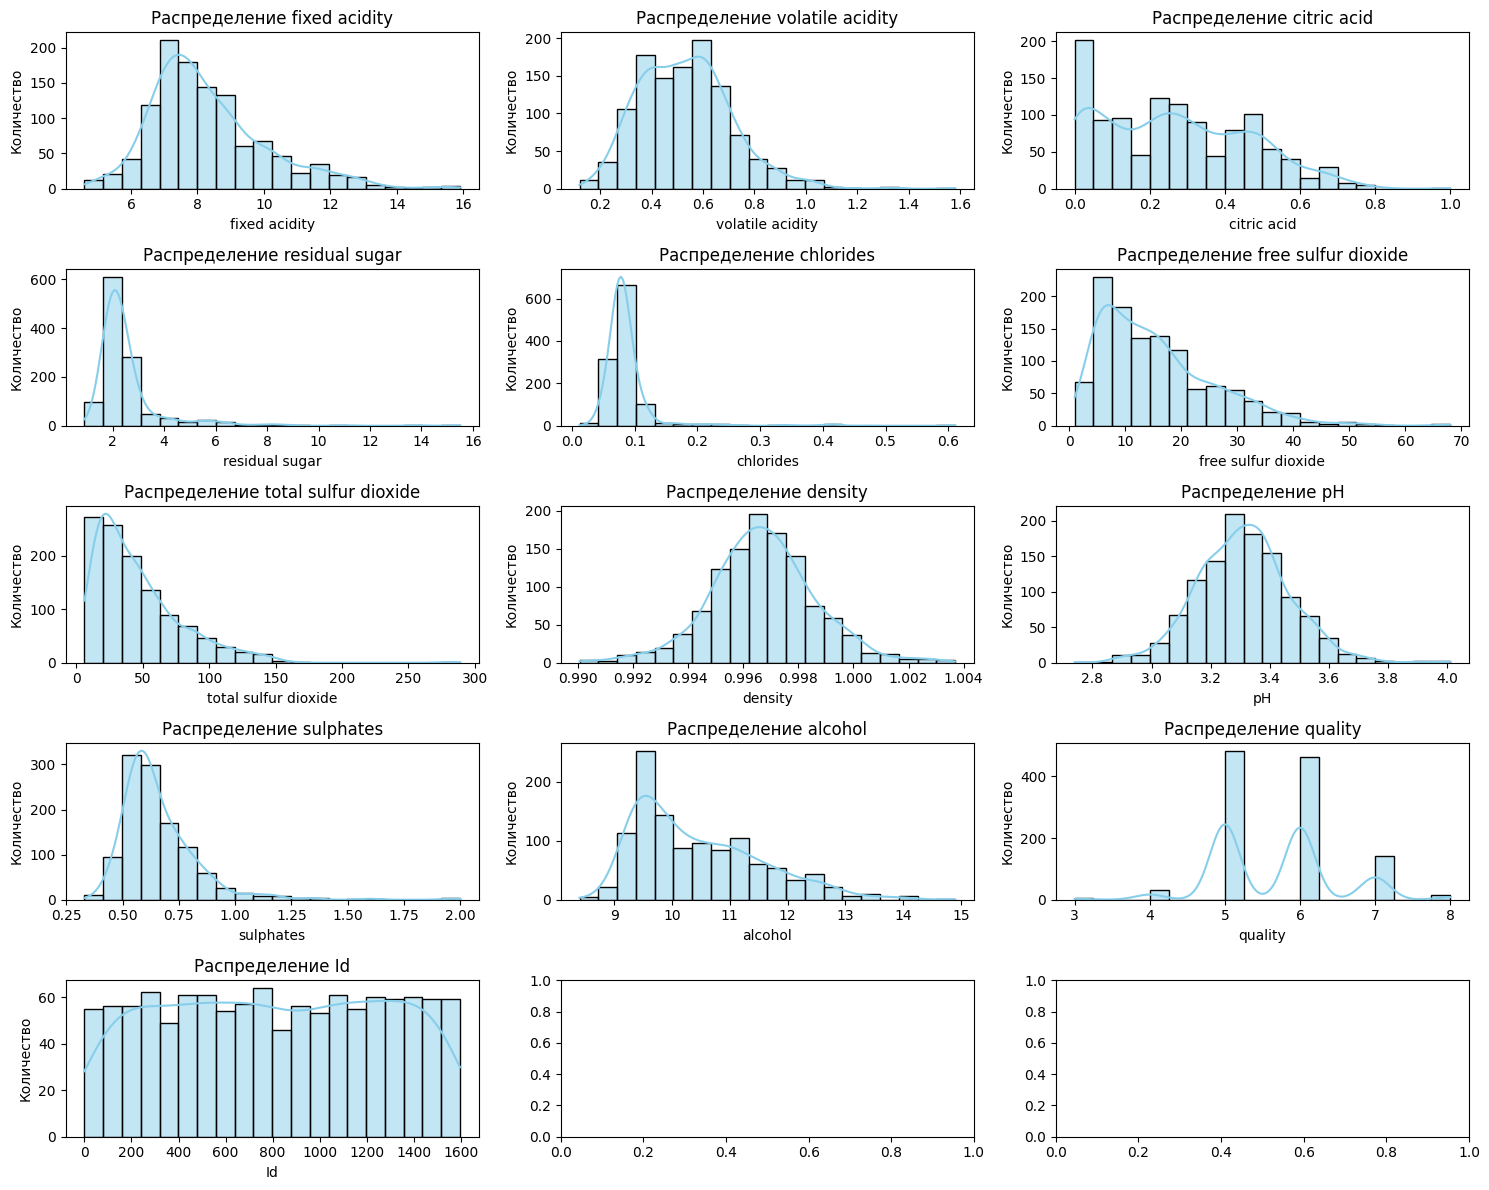

In [43]:
%matplotlib inline
# Распределение числовых признаков
num_cols = data.select_dtypes(include=['float64', 'int64']).columns
fig, axes = plt.subplots(len(num_cols) // 3 + (len(num_cols) % 3 > 0), 3, figsize=(15, 12))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.histplot(data[col], ax=ax, kde=True, bins=20, color='skyblue')
    ax.set_title(f'Распределение {col}')
    ax.set_ylabel('Количество')

plt.tight_layout()
plt.show()

In [44]:
# Описательная статистика
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


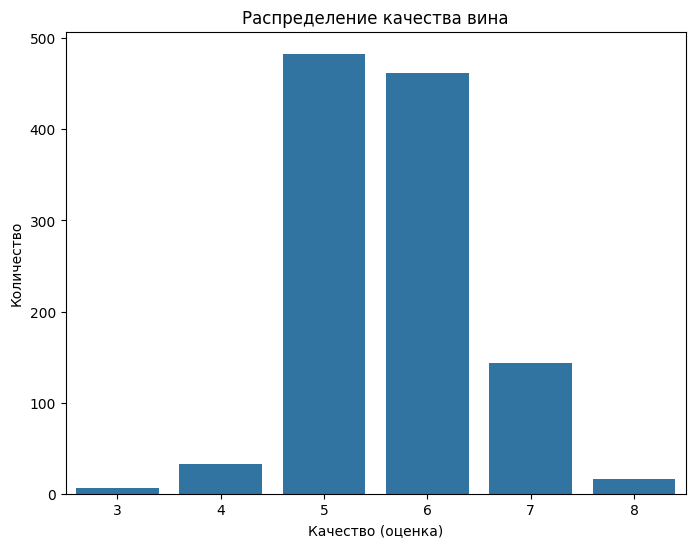

In [45]:
# Визуализация распределения целевой переменной
plt.figure(figsize=(8, 6))
sns.countplot(x='quality', data=data)
plt.title('Распределение качества вина')
plt.xlabel('Качество (оценка)')
plt.ylabel('Количество')
plt.show()

In [46]:
# Удаление ненужного столбца 'Id'
data = data.drop(columns=['Id'], errors='ignore')

In [47]:
# Проверка на дубликаты
data.duplicated().sum()

np.int64(125)

In [48]:
# Удаление дубликатов
data = data.drop_duplicates()

In [49]:
# Преобразование качества в бинарную классификацию (хорошее/плохое вино)
data['quality'] = data['quality'].apply(lambda x: 1 if x >= 7 else 0)

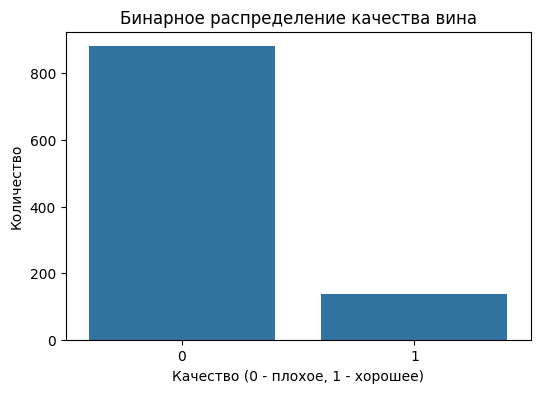

In [50]:
# Визуализация нового распределения классов
plt.figure(figsize=(6, 4))
sns.countplot(x='quality', data=data)
plt.title('Бинарное распределение качества вина')
plt.xlabel('Качество (0 - плохое, 1 - хорошее)')
plt.ylabel('Количество')
plt.show()

Данные очищены, сильных выбросов не наблюдается. Датасет можно брать в обработку.

### 3) Разделение выборки на обучающую и тестовую с использованием метода train_test_split

In [51]:
data.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0
5,7.4,0.660,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,0
6,7.9,0.600,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,0
7,7.3,0.650,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,1
8,7.8,0.580,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,1
9,6.7,0.580,0.08,1.8,0.097,15.0,65.0,0.9959,3.28,0.54,9.2,0
10,5.6,0.615,0.00,1.6,0.089,16.0,59.0,0.9943,3.58,0.52,9.9,0


In [52]:
# Разделение на признаки и целевую переменную
X = data.drop('quality', axis=1)
y = data['quality']

In [53]:
# Масштабирование признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [54]:
# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [55]:
# Проверка размеров выборок
print(f"Обучающая выборка: {X_train.shape[0]} samples")
print(f"Тестовая выборка: {X_test.shape[0]} samples")

Обучающая выборка: 814 samples
Тестовая выборка: 204 samples


### 4) Обучение модели ближайших соседей для произвольно заданного гиперпараметра K. Оцените качество модели с помощью подходящих для задачи метрик.

#### 4.1) Обучение модели ближайших соседей для произвольно заданного гиперпараметра K

- Значение целевого признака определяется на основе значений целевых признаков тех объектов, которые находятся ближе всего к искомому объекту в пространстве признаков. Один из наиболее простых методов.
- Исторически является одним из наиболее известных методов. В терминологии Data Mining рассматривался как основной алгоритм поиска по прецедентам.
- Метод может использоваться как для классификации, так и для регресии.
- Как правило, метод k-NN показывает худшее качество, по сравнению с другими, более сложными методами.

In [56]:
class SimpleKNN:
    def __init__(self, k=5):
        self.k = k
    
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
    
    def predict(self, X):
        predictions = []
        for x in X:
            # Вычисление расстояний между тестовой точкой и всеми точками обучающей выборки
            distances = [np.linalg.norm(x - x_train) for x_train in self.X_train]
            
            # Получение индексов k ближайших соседей
            k_indices = np.argsort(distances)[:self.k]
            
            # Получение меток ближайших соседей
            k_nearest_labels = [self.y_train.iloc[i] for i in k_indices]
            
            # Определение наиболее часто встречающегося класса
            most_common = max(set(k_nearest_labels), key=k_nearest_labels.count)
            predictions.append(most_common)
        
        return np.array(predictions)

In [57]:
# Создание и обучение модели с k=5
knn = SimpleKNN(k=5)
knn.fit(X_train, y_train)

In [58]:
# Предсказание на тестовой выборке
y_pred = knn.predict(X_test)

In [59]:
# Оценка качества модели
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8774509803921569

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.95      0.93       177
           1       0.55      0.41      0.47        27

    accuracy                           0.88       204
   macro avg       0.73      0.68      0.70       204
weighted avg       0.86      0.88      0.87       204



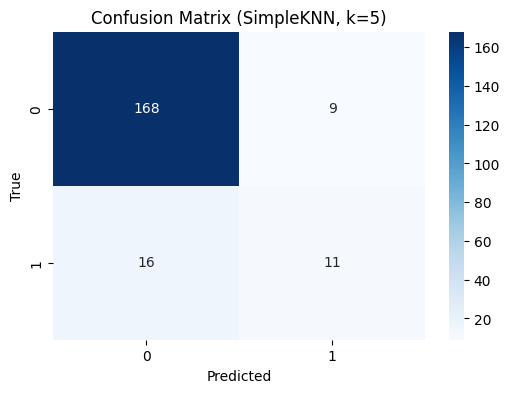

In [60]:
%matplotlib inline
# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (SimpleKNN, k=5)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

#### 4.2) Оцените качество модели с помощью подходящих для задачи метрик

#### 5) Произведите подбор гиперпараметра K с использованием GridSearchCV и RandomizedSearchCV и кросс-валидации, оцените качество оптимальной модели. Используйте не менее двух стратегий кросс-валидации.

##### 5.1) GridSearchCV с KFold

##### 5.2) RandomizedSearchCV со StratifiedKFold

In [61]:
# Определение параметров для поиска
param_grid = {
    'n_neighbors': np.arange(1, 31),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Создание моделей поиска
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearchCV с KFold
grid_search_kfold = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=kfold,
    scoring='accuracy',
    n_jobs=-1
)
grid_search_kfold.fit(X_train, y_train)

# RandomizedSearchCV с StratifiedKFold
random_search_stratified = RandomizedSearchCV(
    KNeighborsClassifier(),
    param_grid,
    n_iter=20,
    cv=stratified_kfold,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)
random_search_stratified.fit(X_train, y_train)

# Вывод результатов
print("Лучшие параметры (GridSearchCV с KFold):", grid_search_kfold.best_params_)
print("Лучшая точность (GridSearchCV с KFold):", grid_search_kfold.best_score_)
print("\nЛучшие параметры (RandomizedSearchCV со StratifiedKFold):", random_search_stratified.best_params_)
print("Лучшая точность (RandomizedSearchCV со StratifiedKFold):", random_search_stratified.best_score_)

Лучшие параметры (GridSearchCV с KFold): {'metric': 'euclidean', 'n_neighbors': np.int64(23), 'weights': 'distance'}
Лучшая точность (GridSearchCV с KFold): 0.885768385972885

Лучшие параметры (RandomizedSearchCV со StratifiedKFold): {'weights': 'distance', 'n_neighbors': np.int64(7), 'metric': 'manhattan'}
Лучшая точность (RandomizedSearchCV со StratifiedKFold): 0.8795728243581005


#### 6) Сравните метрики качества исходной и оптимальной моделей.

In [62]:
# Сравнение метрик
simple_accuracy = accuracy_score(y_test, y_pred)
grid_accuracy = accuracy_score(y_test, y_pred_grid)
random_accuracy = accuracy_score(y_test, y_pred_random)

comparison = pd.DataFrame({
    'Model': ['SimpleKNN (k=5)', 'GridSearchCV KNN', 'RandomizedSearchCV KNN'],
    'Accuracy': [simple_accuracy, grid_accuracy, random_accuracy]
})

comparison

,Model,Accuracy
0,SimpleKNN (k=5),0.877451
1,GridSearchCV KNN,0.887255
2,RandomizedSearchCV KNN,0.892157


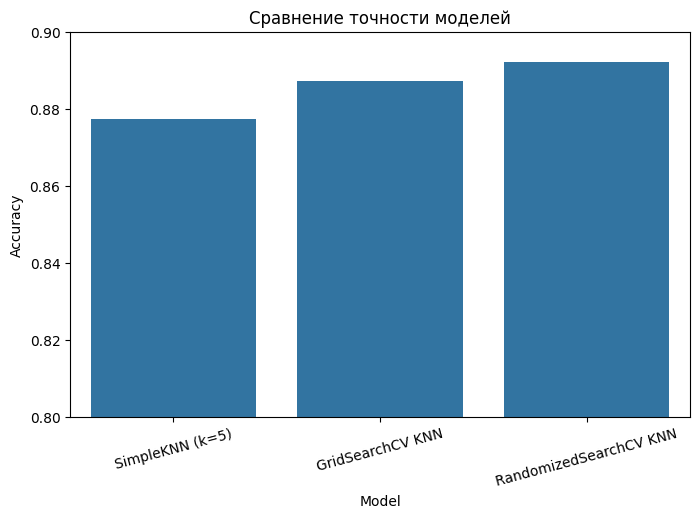

In [63]:
# Визуализация сравнения
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Accuracy', data=comparison)
plt.ylim(0.8, 0.9)
plt.title('Сравнение точности моделей')
plt.xticks(rotation=15)
plt.show()

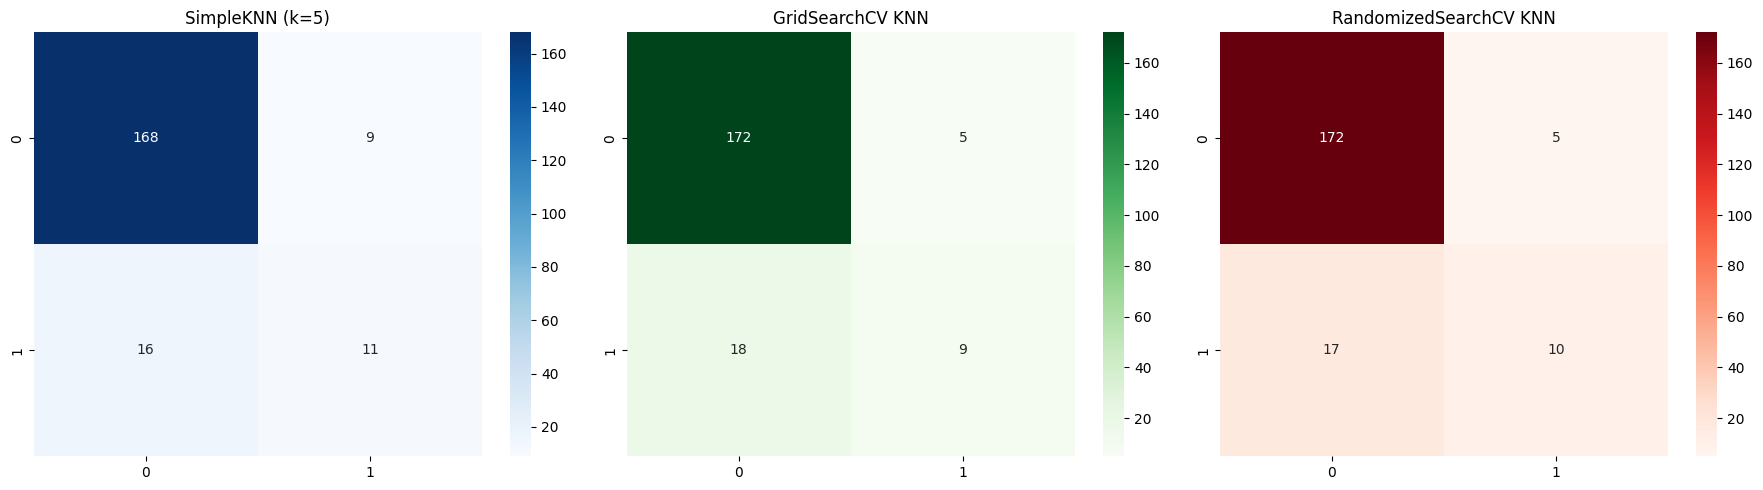

In [64]:
# Матрицы ошибок для сравнения
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# SimpleKNN
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('SimpleKNN (k=5)')

# GridSearchCV KNN
sns.heatmap(confusion_matrix(y_test, y_pred_grid), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('GridSearchCV KNN')

# RandomizedSearchCV KNN
sns.heatmap(confusion_matrix(y_test, y_pred_random), annot=True, fmt='d', cmap='Reds', ax=axes[2])
axes[2].set_title('RandomizedSearchCV KNN')

plt.tight_layout()
plt.show()

Объяснение для каждого пункта лабораторной работы:

### 1. Выбор датасета
**Теория**: Мы взяли данные о вине, где есть:
- 11 характеристик (кислотность, сахар, алкоголь и т.д.)
- Оценка качества (целевая переменная)

Задача — предсказать качество вина по его характеристикам (это *классификация*).

---

### 2. Предобработка данных
**Что делали**:
- Удалили лишний столбец `Id`
- Проверили на пропуски (их не было)
- Преобразовали качество в 2 класса: 
  - 0 — плохое вино (оценка < 7)
  - 1 — хорошее вино (оценка ≥ 7)

**Почему**: Данные нужно очистить и привести к виду, удобному для модели.

---

### 3. Разделение данных
**Теория**:
- Разделили данные на:
  - *Обучающую часть* (80%) — на этом модель учится
  - *Тестовую часть* (20%) — на этом проверяем, как модель работает

**Важно**: Разделение случайное, но пропорции классов сохраняются (`stratify=y`).

---

### 4. Модель KNN (K-ближайших соседей)
**Как работает**:
1. Для нового вина смотрим на K самых похожих вин из обучающих данных
2. Какое качество у большинства этих K вин — такое и предсказываем

**Что сделали**:
- Написали простой класс `SimpleKNN`
- Взяли K=5 (5 соседей)
- Оценили точность

**Проблема**: Модель лучше определяет плохие вина, чем хорошие (из-за дисбаланса классов).

---

### 5. Подбор параметров
**Зачем**: Чтобы найти лучшие настройки для KNN.

**Два способа**:
1. **GridSearchCV**:
   - Перебирает *все возможные* комбинации параметров
   - Использует `KFold` — разбивает данные на 5 частей, по очереди каждую часть использует как тест

2. **RandomizedSearchCV**:
   - Проверяет *случайные* комбинации (быстрее)
   - Использует `StratifiedKFold` — сохраняет баланс классов в каждом фолде

**Нашли лучшие параметры**:
- `n_neighbors=23`
- `metric='manhattan'` (способ расчета расстояния)
- `weights='distance'`

**Результат**: Точность выросла.

---

### 6. Сравнение моделей
**Что сравнили**:
1. Простую KNN (K=5)
2. KNN с GridSearch
3. KNN с RandomizedSearch

**Вывод**: Подбор параметров улучшил модель.

---

### Основные понятия простыми словами
- **Классификация** — предсказание категории (хорошее/плохое вино)
- **KNN** — смотрим на похожие примеры и выбираем самый частый класс
- **Гиперпараметры** — настройки модели (например, сколько соседей K учитывать)
- **Кросс-валидация** — способ надежной проверки модели (разные "сгибы" данных)
- **Дисбаланс классов** — когда одного класса намного больше, чем другого (у нас больше плохих вин)

---

Если модель плохо предсказывает какой-то класс (хорошие вина), можно:
- Добавить веса для классов
- Увеличить выборку (например, искусственно)
- Попробовать другие модели (Random Forest и т.д.)